# Client: ABC Tech | Category: ITSM -
# ML Project Ref: PM-PR-0012

# ITSM Process Optimization using Machine Learning

## Problem Statement

ABC Tech is a mid-sized IT-enabled organization that receives a large volume of IT incidents and service tickets. Although the organization follows mature ITIL-based practices across incident management, problem management, change management, and configuration management, recent customer survey results indicate that the incident management process is still rated poorly.

The objective of this project is to use machine learning and data analytics to improve ITSM operations by predicting ticket priority, forecasting incident volume, supporting ticket auto-tagging, and analyzing change-related risk.

This project uses historical ITSM ticket data queried from a MySQL database and follows a complete data science workflow, including database connection, data extraction, data understanding, data cleaning, exploratory data analysis, feature engineering, machine learning model development, forecasting, evaluation, and final business recommendations.

## Business Objectives

Based on the project document, the business objectives are divided into four major modules:

### 1. High Priority Ticket Prediction

Predict high-priority incidents, especially Priority 1 and Priority 2 tickets, so that preventive measures can be taken before issues escalate.

### 2. Incident Volume Forecasting

Forecast incident volume across different time periods such as quarterly and yearly trends to support resource planning and technology planning.

### 3. Ticket Auto-Tagging

Automatically assign appropriate priorities and departments or categories to incidents, reducing reassignment delays and improving ticket routing efficiency.

### 4. Change Request Risk Analysis

Analyze request-for-change records and related incident/change information to identify possible failure, misconfiguration, or operational risk associated with ITSM assets.

## Project Workflow

This project is organized into the following sections:

1. Database Connection and Data Extraction  
2. Data Understanding and Inspections
3. Data Cleaning and Type Conversion  
4. Exploratory Data Analysis  
5. Module 1: High Priority Ticket Prediction  
6. Module 2: Incident Volume Forecasting  
7. Module 3: Ticket Auto-Tagging  
8. Module 4: Change Request Risk Analysis  
9. Final Business Recommendations  
10. Conclusion  
11. Final Project Report

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Database connection
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

## Database Connection and Data Extraction

In [2]:
pip install pymysql sqlalchemy pandas

In [3]:
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

HOST = "18.136.157.135"
USER = "dm_team"
PASSWORD = "DM!$Team@&27920!"
DATABASE = "project_itsm"

connection_url = URL.create(
    drivername="mysql+pymysql",
    username=USER,
    password=PASSWORD,
    host=HOST,
    port=3306,
    database=DATABASE
)

engine = create_engine(
    connection_url,
    pool_pre_ping=True,
    connect_args={"connect_timeout": 15}
)

try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT DATABASE();"))
        print("✅ Successfully connected!")
        print("Database:", result.scalar())

except Exception as e:
    print("❌ Connection failed:")
    print(e)

✅ Successfully connected!
Database: project_itsm


In [4]:
query = "SHOW TABLES;"
tables = pd.read_sql(query, engine)
tables

,Tables_in_project_itsm
0,dataset_list


In [12]:
df.to_csv('itsm.csv')

## Data Understanding and Initial Inspection

The ITSM dataset was queried from the MySQL database using read-only access. After establishing a successful database connection, the available table was identified and loaded into a pandas DataFrame for further analysis.

### Dataset Overview

The extracted ITSM dataset is inspected to understand its structure, dimensions, column types, and sample records before performing data cleaning or preprocessing.

In [10]:
df = pd.read_sql("SELECT * FROM dataset_list", engine)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (46606, 25)


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Name                     46606 non-null  object
 1   CI_Cat                      46606 non-null  object
 2   CI_Subcat                   46606 non-null  object
 3   WBS                         46606 non-null  object
 4   Incident_ID                 46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   number_cnt                  46606 non-null  object
 10  Category                    46606 non-null  object
 11  KB_number                   46606 non-null  object
 12  Alert_Status                46606 non-null  object
 13  No_of_Reassignments         46606 non-null  ob

### Data Quality Assessment

A data quality assessment is performed to identify missing values, data types, and unique value counts for each column. This helps determine the cleaning and type conversion steps required before analysis and modeling.

In [14]:
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean() * 100, 2),
    "Unique Values": df.nunique()
})

display(quality_summary)

,Data Type,Missing Values,Missing Percentage,Unique Values
CI_Name,object,0,0.0,3019
CI_Cat,object,0,0.0,13
CI_Subcat,object,0,0.0,65
WBS,object,0,0.0,274
Incident_ID,object,0,0.0,46606
Status,object,0,0.0,2
Impact,object,0,0.0,6
Urgency,object,0,0.0,6
Priority,object,0,0.0,6
number_cnt,object,0,0.0,46606


In [15]:
df.describe(include="all").T

,count,unique,top,freq
CI_Name,46606,3019,SUB000456,3050
CI_Cat,46606,13,application,32900
CI_Subcat,46606,65,Server Based Application,18811
WBS,46606,274,WBS000073,13342
Incident_ID,46606,46606,IM0047057,1
Status,46606,2,Closed,46597
Impact,46606,6,4,22556
Urgency,46606,6,4,22588
Priority,46606,6,4,22717
number_cnt,46606,46606,0.902319509,1


### Target Variable Distribution

The `Priority` column is inspected to understand the distribution of ticket priority levels and identify class imbalance before defining the final machine learning target.

In [16]:
df["Priority"].value_counts(dropna=False).sort_index()

Priority
1         3
2       697
3      5323
4     22717
5     16486
NA     1380
Name: count, dtype: int64

In [17]:
round(df["Priority"].value_counts(normalize=True, dropna=False).sort_index() * 100, 2)

Priority
1      0.01
2      1.50
3     11.42
4     48.74
5     35.37
NA     2.96
Name: proportion, dtype: float64

#### Initial Data Inspection Summary

The ITSM dataset contains 46,606 incident records and 25 columns. Although the initial missing value check showed no null values, further inspection revealed that several missing values are represented as blank strings or text values such as `NA`. Therefore, these values need to be converted into proper missing values during data cleaning.

Most columns were imported as object data types, including numeric fields such as impact, urgency, priority, reassignment count, handle time, and related ticket counts. These columns require appropriate type conversion before analysis and modeling.

The target column, `Priority`, contains five priority levels along with `NA` values. The distribution is highly imbalanced, with Priority 4 and Priority 5 forming the majority of records, while Priority 1 contains only a very small number of observations. Because of this imbalance, direct five-class classification may not be reliable.

For a practical multiclass machine learning problem, priority levels can be grouped into three broader categories: High Priority, Medium Priority, and Low Priority. Rows with missing priority values will be removed before model development.

## Data Cleaning and Type Conversion

The initial inspection showed that several missing values are stored as blank strings or text values such as `NA`. Also, many numeric and datetime columns were imported as object data types. Therefore, cleaning is required before analysis and modeling.

### Handling Blank and Placeholder Missing Values

Blank strings and placeholder values such as `NA` are converted into proper missing values so that missing data can be measured accurately.

In [18]:
df_clean = df.copy()

df_clean = df_clean.replace(r"^\s*$", np.nan, regex=True)
df_clean = df_clean.replace(["NA", "N/A", "nan", "NaN"], np.nan)

missing_summary = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": round(df_clean.isnull().mean() * 100, 2)
}).sort_values(by="Missing Percentage", ascending=False)

display(missing_summary)

,Missing Values,Missing Percentage
Related_Change,46046,98.80
No_of_Related_Changes,46046,98.80
No_of_Related_Incidents,45384,97.38
Reopen_Time,44322,95.10
Resolved_Time,1780,3.82
Priority,1380,2.96
Closure_Code,460,0.99
CI_Subcat,111,0.24
CI_Cat,111,0.24
No_of_Related_Interactions,114,0.24


### Type Conversion

Numeric and datetime columns are converted into appropriate data types. This step ensures that numerical analysis, time-based feature engineering, and machine learning preprocessing can be performed correctly.

In [19]:
numeric_columns = [
    "Impact",
    "Urgency",
    "Priority",
    "No_of_Reassignments",
    "Handle_Time_hrs",
    "No_of_Related_Interactions",
    "No_of_Related_Incidents",
    "No_of_Related_Changes"
]

for col in numeric_columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [20]:
datetime_columns = [
    "Open_Time",
    "Reopen_Time",
    "Resolved_Time",
    "Close_Time"
]

for col in datetime_columns:
    df_clean[col] = pd.to_datetime(
        df_clean[col],
        errors="coerce",
        dayfirst=True
    )

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     46606 non-null  object        
 1   CI_Cat                      46495 non-null  object        
 2   CI_Subcat                   46495 non-null  object        
 3   WBS                         46606 non-null  object        
 4   Incident_ID                 46606 non-null  object        
 5   Status                      46606 non-null  object        
 6   Impact                      45226 non-null  float64       
 7   Urgency                     46605 non-null  float64       
 8   Priority                    45226 non-null  float64       
 9   number_cnt                  46606 non-null  object        
 10  Category                    46606 non-null  object        
 11  KB_number                   46606 non-null  object    

In [22]:
cleaning_summary = pd.DataFrame({
    "Data Type": df_clean.dtypes,
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": round(df_clean.isnull().mean() * 100, 2),
    "Unique Values": df_clean.nunique()
})

display(cleaning_summary)

,Data Type,Missing Values,Missing Percentage,Unique Values
CI_Name,object,0,0.00,3019
CI_Cat,object,111,0.24,12
CI_Subcat,object,111,0.24,64
WBS,object,0,0.00,274
Incident_ID,object,0,0.00,46606
Status,object,0,0.00,2
Impact,float64,1380,2.96,5
Urgency,float64,1,0.00,5
Priority,float64,1380,2.96,5
number_cnt,object,0,0.00,46606


#### Data Cleaning Summary

After replacing blank strings and placeholder values such as `NA`, the dataset showed several true missing values that were not visible during the initial inspection.

The columns `Priority` and `Impact` contain missing values in 1,380 records, while columns such as `Reopen_Time`, `No_of_Related_Incidents`, `No_of_Related_Changes`, and `Related_Change` contain a very high percentage of missing values.

Numeric fields such as `Impact`, `Urgency`, `Priority`, `No_of_Reassignments`, `Handle_Time_hrs`, and related ticket counts were converted into numerical data types. Time-based fields including `Open_Time`, `Reopen_Time`, `Resolved_Time`, and `Close_Time` were converted into datetime format.

This cleaned dataset will be used for further analysis, target preparation, and feature engineering.

### Removing Low-Value and High-Missing Columns

Columns with very high missing percentages, constant values, unique identifiers, or post-resolution information are removed because they do not provide useful predictive information or may introduce data leakage.

In [23]:
columns_to_drop = [
    "Incident_ID",
    "number_cnt",
    "Alert_Status",
    "Reopen_Time",
    "Resolved_Time",
    "Close_Time",
    "Handle_Time_hrs",
    "Related_Interaction",
    "Related_Change",
    "No_of_Related_Incidents",
    "No_of_Related_Changes"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Dataset Shape After Dropping Columns:", df_clean.shape)

Dataset Shape After Dropping Columns: (46606, 14)


In [24]:
df_clean.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,Category,KB_number,No_of_Reassignments,Open_Time,Closure_Code,No_of_Related_Interactions
0,SUB000508,subapplication,Web Based Application,WBS000162,Closed,4.0,4.0,4.0,incident,KM0000553,26.0,2012-02-05 13:32:00,Other,1.0
1,WBA000124,application,Web Based Application,WBS000088,Closed,3.0,3.0,3.0,incident,KM0000611,33.0,2012-03-12 15:44:00,Software,1.0
2,DTA000024,application,Desktop Application,WBS000092,Closed,NaN,3.0,NaN,request for information,KM0000339,3.0,2012-03-29 12:36:00,No error - works as designed,1.0
3,WBA000124,application,Web Based Application,WBS000088,Closed,4.0,4.0,4.0,incident,KM0000611,13.0,2012-07-17 11:49:00,Operator error,1.0
4,WBA000124,application,Web Based Application,WBS000088,Closed,4.0,4.0,4.0,incident,KM0000611,2.0,2012-08-10 11:01:00,Other,1.0


### Target Preparation

The original `Priority` column contains five priority levels along with missing values. Since Priority 1 has very few records, direct five-class classification would not be reliable. Therefore, the priority levels are grouped into three broader business categories: High, Medium, and Low priority.

In [25]:
df_clean = df_clean.dropna(subset=["Priority"])

def group_priority(priority):
    if priority in [1, 2]:
        return "High"
    elif priority == 3:
        return "Medium"
    elif priority in [4, 5]:
        return "Low"
    else:
        return np.nan

df_clean["Priority_Group"] = df_clean["Priority"].apply(group_priority)

df_clean = df_clean.dropna(subset=["Priority_Group"])

print("Dataset Shape After Target Preparation:", df_clean.shape)

display(
    pd.DataFrame({
        "Count": df_clean["Priority_Group"].value_counts(),
        "Percentage": round(
            df_clean["Priority_Group"].value_counts(normalize=True) * 100,
            2
        )
    })
)

Dataset Shape After Target Preparation: (45226, 15)


,Count,Percentage
Priority_Group,,
Low,39203,86.68
Medium,5323,11.77
High,700,1.55


#### Target Preparation Summary

Rows with missing priority values were removed because they cannot be used for supervised learning. The original priority levels were grouped into three business-relevant categories: High priority for Priority 1 and 2, Medium priority for Priority 3, and Low priority for Priority 4 and 5.

This grouping converts the target into a practical multiclass classification problem while reducing the issue caused by extremely rare priority classes.

### Target Leakage Check

The project document includes a priority matrix where ticket priority is determined using impact and urgency values. Because of this, `Impact` and `Urgency` may directly reveal the target variable and create data leakage if used for priority prediction.

To build a more realistic machine learning model, the relationship between `Impact`, `Urgency`, and the grouped priority target is examined before deciding whether these columns should be used as predictors.

In [26]:
pd.crosstab(
    index=[df_clean["Impact"], df_clean["Urgency"]],
    columns=df_clean["Priority_Group"],
    normalize="index"
).round(2)

Priority_Group  High  Low  Medium
Impact Urgency                   
1.0    1.0       1.0  0.0     0.0
2.0    2.0       1.0  0.0     0.0
       3.0       1.0  0.0     0.0
3.0    1.0       1.0  0.0     0.0
       2.0       1.0  0.0     0.0
       3.0       0.0  0.0     1.0
       4.0       0.0  0.0     1.0
       5.0       0.0  1.0     0.0
4.0    2.0       0.0  0.0     1.0
       3.0       0.0  0.0     1.0
       4.0       0.0  1.0     0.0
       5.0       0.0  1.0     0.0
5.0    1.0       0.0  0.0     1.0
       2.0       0.0  0.0     1.0
       3.0       0.0  1.0     0.0
       4.0       0.0  1.0     0.0
       5.0       0.0  1.0     0.0

In [27]:
pd.crosstab(
    index=df_clean["Priority"],
    columns=df_clean["Priority_Group"]
)

Priority_Group,High,Low,Medium
Priority,,,
1.0,3,0,0
2.0,697,0,0
3.0,0,0,5323
4.0,0,22717,0
5.0,0,16486,0


#### Target Leakage Summary

`Impact` and `Urgency` are closely related to ticket priority because the priority level is defined using an impact-urgency matrix. Including these columns in the priority prediction model may lead to overly optimistic results.

Therefore, for a realistic predictive model, `Impact`, `Urgency`, and the original `Priority` column will be removed from the feature set. The model will instead use incident-related, configuration-item, category, time-based, and reassignment-related features to predict the grouped priority class.

In [28]:
df_model = df_clean.drop(columns=["Impact", "Urgency", "Priority"])

print("Modeling Dataset Shape:", df_model.shape)
display(df_model.head())

Modeling Dataset Shape: (45226, 12)


,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Category,KB_number,No_of_Reassignments,Open_Time,Closure_Code,No_of_Related_Interactions,Priority_Group
0,SUB000508,subapplication,Web Based Application,WBS000162,Closed,incident,KM0000553,26.0,2012-02-05 13:32:00,Other,1.0,Low
1,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,33.0,2012-03-12 15:44:00,Software,1.0,Medium
3,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,13.0,2012-07-17 11:49:00,Operator error,1.0,Low
4,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,2.0,2012-08-10 11:01:00,Other,1.0,Low
5,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,4.0,2012-08-10 11:27:00,Other,1.0,Low


## Feature Engineering

Feature engineering is performed to extract useful information from available incident attributes. Since the raw dataset contains an incident opening timestamp, time-based features are created to capture ticket patterns across year, month, day, weekday, and hour.

### Time-Based Feature Creation

The `Open_Time` column is used to create new time-based features that may help identify incident patterns across different periods.

In [29]:
df_model["Open_Year"] = df_model["Open_Time"].dt.year
df_model["Open_Month"] = df_model["Open_Time"].dt.month
df_model["Open_Day"] = df_model["Open_Time"].dt.day
df_model["Open_Weekday"] = df_model["Open_Time"].dt.dayofweek
df_model["Open_Hour"] = df_model["Open_Time"].dt.hour

df_model = df_model.drop(columns=["Open_Time"])

print("Dataset Shape After Feature Engineering:", df_model.shape)
display(df_model.head())

Dataset Shape After Feature Engineering: (45226, 16)


,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Category,KB_number,No_of_Reassignments,Closure_Code,No_of_Related_Interactions,Priority_Group,Open_Year,Open_Month,Open_Day,Open_Weekday,Open_Hour
0,SUB000508,subapplication,Web Based Application,WBS000162,Closed,incident,KM0000553,26.0,Other,1.0,Low,2012,2,5,6,13
1,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,33.0,Software,1.0,Medium,2012,3,12,0,15
3,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,13.0,Operator error,1.0,Low,2012,7,17,1,11
4,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,2.0,Other,1.0,Low,2012,8,10,4,11
5,WBA000124,application,Web Based Application,WBS000088,Closed,incident,KM0000611,4.0,Other,1.0,Low,2012,8,10,4,11


#### Feature Engineering Summary

Time-based features were extracted from the incident opening timestamp to represent when incidents were reported. These features may help capture operational patterns such as monthly trends, weekday effects, and hour-based ticket activity.

After extracting these features, the original `Open_Time` column was removed because the useful information from it has already been converted into structured numerical variables.

## Exploratory Data Analysis

Exploratory Data Analysis is performed to understand ticket distribution, target class balance, categorical feature patterns, and time-based incident trends before model development.

### Target Distribution

The grouped priority target is analyzed to understand class balance across High, Medium, and Low priority incidents.

,Count,Percentage
Priority_Group,,
Low,39203,86.68
Medium,5323,11.77
High,700,1.55


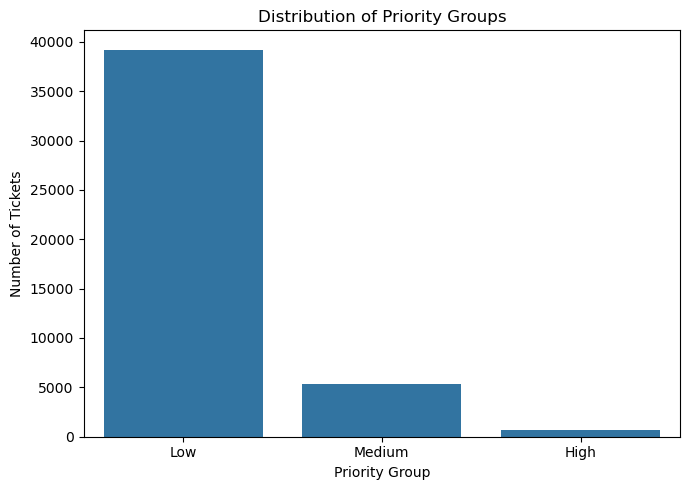

In [30]:
priority_distribution = pd.DataFrame({
    "Count": df_model["Priority_Group"].value_counts(),
    "Percentage": round(
        df_model["Priority_Group"].value_counts(normalize=True) * 100,
        2
    )
})

display(priority_distribution)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_model,
    x="Priority_Group",
    order=df_model["Priority_Group"].value_counts().index
)

plt.title("Distribution of Priority Groups")
plt.xlabel("Priority Group")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

### Ticket Category Analysis

Ticket category distribution is examined to understand the types of ITSM records present in the dataset.

In [31]:
category_distribution = pd.DataFrame({
    "Count": df_model["Category"].value_counts(),
    "Percentage": round(df_model["Category"].value_counts(normalize=True) * 100, 2)
})

display(category_distribution)

,Count,Percentage
Category,,
incident,36413,80.51
request for information,8801,19.46
complaint,11,0.02
request for change,1,0.00


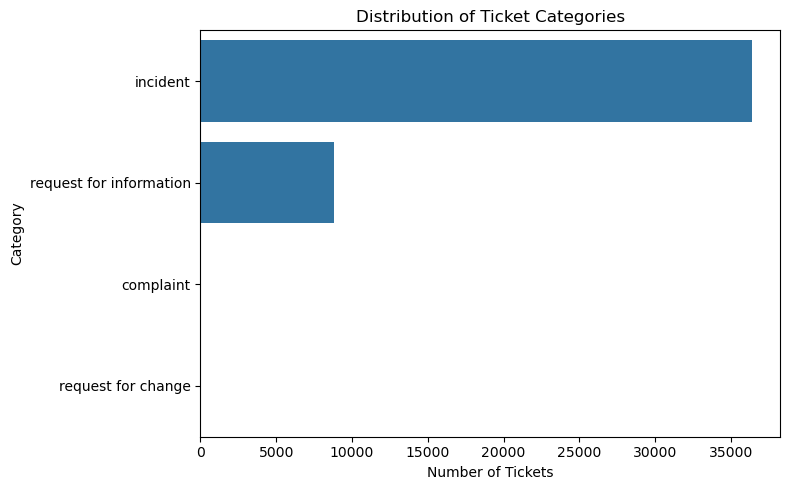

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    y="Category",
    order=df_model["Category"].value_counts().index
)

plt.title("Distribution of Ticket Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

#### Ticket Category Summary

The dataset is mainly dominated by incident records, while other ticket categories occur less frequently. This shows that the dataset is primarily focused on incident management, which aligns with the objective of improving ITSM incident handling.

### Priority Group by Ticket Category

The relationship between ticket category and priority group is analyzed to understand whether certain ticket categories are more associated with High, Medium, or Low priority incidents.

Priority_Group,High,Low,Medium
Category,,,
complaint,0.00,1.00,0.00
incident,0.02,0.84,0.14
request for change,0.00,1.00,0.00
request for information,0.00,0.98,0.02


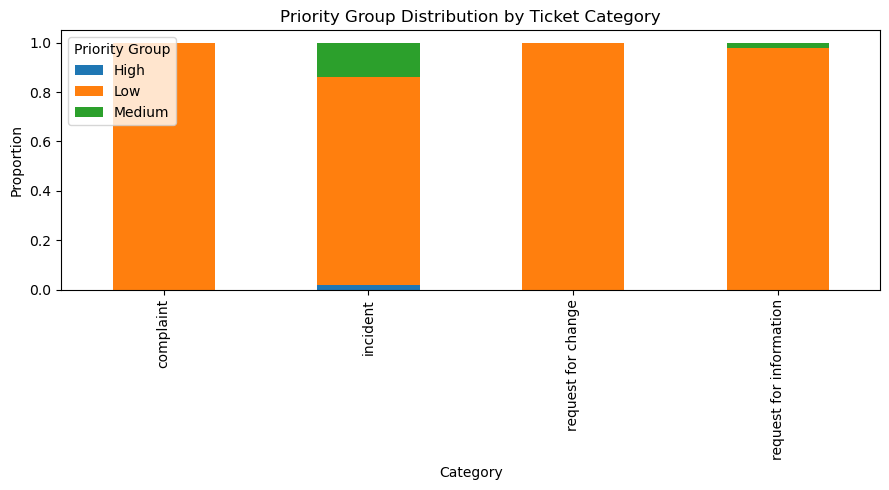

In [33]:
category_priority = pd.crosstab(
    df_model["Category"],
    df_model["Priority_Group"],
    normalize="index"
).round(2)

display(category_priority)

category_priority.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Priority Group Distribution by Ticket Category")
plt.xlabel("Category")
plt.ylabel("Proportion")
plt.legend(title="Priority Group")
plt.tight_layout()
plt.show()

#### Category-Priority Summary

The priority distribution varies across ticket categories, indicating that ticket category may provide useful information for predicting priority group. However, the overall imbalance remains visible, with Low priority tickets forming the largest share across most categories.

### Time-Based Incident Trends

Time-based features extracted from the incident opening timestamp are analyzed to identify ticket patterns across year, month, weekday, and hour.

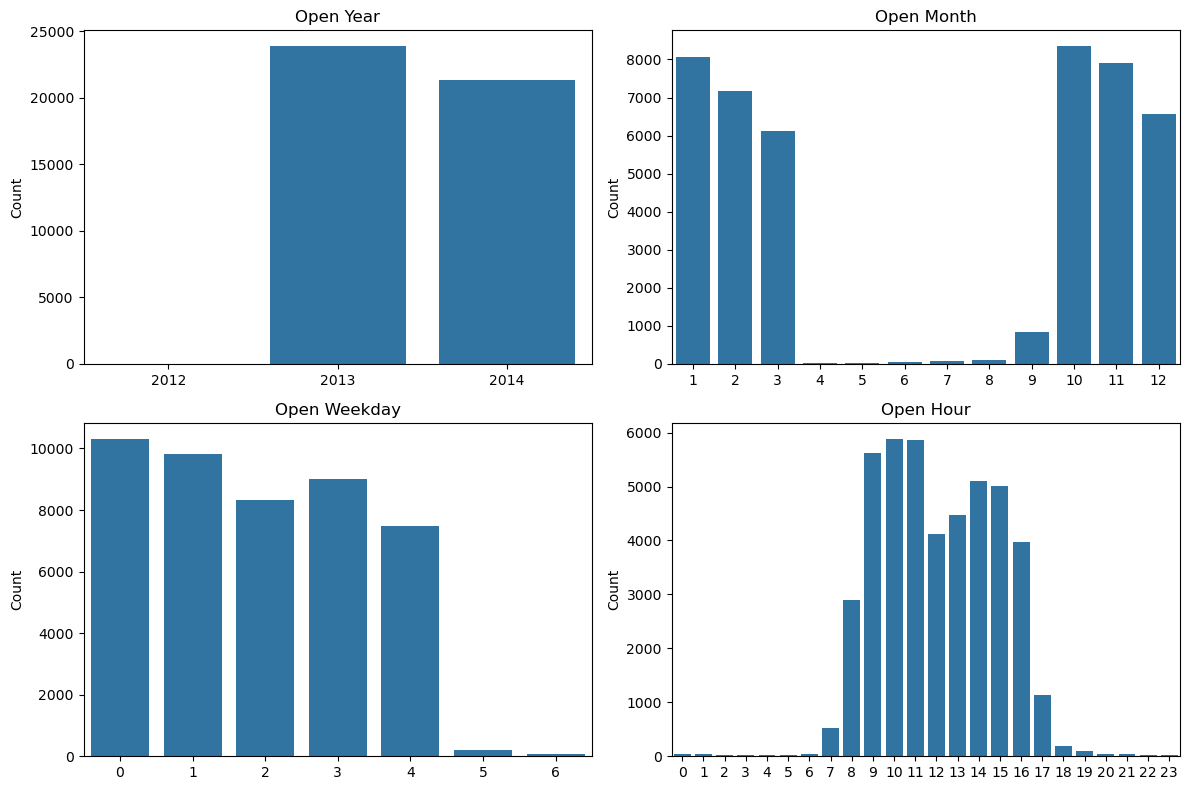

In [34]:
time_features = ["Open_Year", "Open_Month", "Open_Weekday", "Open_Hour"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), time_features):
    sns.countplot(data=df_model, x=feature, ax=ax)
    ax.set_title(feature.replace("_", " "))
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

#### Time-Based Trend Summary

The time-based analysis shows how incidents are distributed across different years, months, weekdays, and hours. These features can help capture operational ticket patterns and may contribute useful information during model training.

#### EDA Summary

The exploratory analysis shows that the priority target is highly imbalanced, with Low priority tickets forming the majority and High priority tickets being very rare. The dataset is mainly composed of incident records, making it suitable for ITSM incident management analysis.

Category-level analysis indicates that ticket category has some relationship with priority group, although Low priority remains dominant across most categories. Time-based analysis also reveals clear operational patterns across months, weekdays, and business hours.

These findings support the use of categorical, operational, and time-based features for the first modeling module: High Priority Ticket Prediction.

## Module 1: High Priority Ticket Prediction
This module focuses on predicting whether an ITSM ticket belongs to a High, Medium, or Low priority group using incident-related, categorical, operational, and time-based features.

Since the target variable is highly imbalanced, Macro F1-score will be used as the main evaluation metric.

### Feature and Target Separation

The target variable is separated from the predictor variables before model training. The grouped priority column is used as the final multiclass target.

In [35]:
X = df_model.drop(columns=["Priority_Group"])
y = df_model["Priority_Group"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (45226, 15)
Target Shape: (45226,)


### Train-Test Split

The dataset is split into training and testing sets using stratification to preserve the class distribution of the priority groups.m

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining Target Distribution:")
display(y_train.value_counts(normalize=True).round(4))

print("\nTesting Target Distribution:")
display(y_test.value_counts(normalize=True).round(4))

X_train: (36180, 15)
X_test : (9046, 15)

Training Target Distribution:


Priority_Group
Low       0.8668
Medium    0.1177
High      0.0155
Name: proportion, dtype: float64


Testing Target Distribution:


Priority_Group
Low       0.8668
Medium    0.1177
High      0.0155
Name: proportion, dtype: float64

#### Train-Test Split Summary

The dataset was split into training and testing sets using stratification. The class distribution remained consistent across both sets, ensuring that the rare High priority class is represented in both training and testing data.

The training set contains 36,180 records, while the testing set contains 9,046 records.

### Preprocessing Pipeline

Categorical and numerical columns are identified separately. Missing values are handled using simple imputation, categorical variables are encoded using One-Hot Encoding, and numerical variables are scaled for models that require standardized input.

In [37]:
categorical_columns = X_train.select_dtypes(include="object").columns.tolist()
numerical_columns = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:", len(categorical_columns))
print("Numerical Columns:", len(numerical_columns))

Categorical Columns: 8
Numerical Columns: 7


In [38]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

#### Preprocessing Summary

The feature set contains 8 categorical columns and 7 numerical columns. Numerical columns are imputed using the median and scaled using StandardScaler. Categorical columns are imputed using the most frequent value and encoded using One-Hot Encoding.

This preprocessing setup will be applied inside machine learning pipelines to avoid data leakage.

### Baseline Model Development

Baseline classification models are trained to evaluate how well different algorithms predict the grouped ticket priority. Since the target variable is highly imbalanced, Macro F1-score is used as the main comparison metric.

In [39]:
model_results = []

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    global model_results
    model_results = [
        result for result in model_results
        if result["Model"] != model_name
    ]

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": macro_f1
    })

    print(model_name)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("Macro F1 :", round(macro_f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return y_pred

### Logistic Regression

Logistic Regression is used as the first baseline model. It provides a simple linear benchmark for comparing more complex machine learning models.

In [40]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_predictions = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Logistic Regression
Accuracy : 0.9124
Precision: 0.6529
Recall   : 0.8409
Macro F1 : 0.7011

Classification Report:
              precision    recall  f1-score   support

        High       0.25      0.77      0.38       140
         Low       0.98      0.93      0.95      7841
      Medium       0.73      0.82      0.77      1065

    accuracy                           0.91      9046
   macro avg       0.65      0.84      0.70      9046
weighted avg       0.94      0.91      0.92      9046



#### Logistic Regression Summary

Logistic Regression achieved an accuracy of **91.21%** and a Macro F1-score of **0.7003**. The model performed well overall, especially for the majority Low priority class.

For the High priority class, recall was strong at **0.77**, meaning the model identified most high-priority tickets. However, precision was low at **0.25**, indicating that many predicted High priority tickets were false positives.

This result provides a strong baseline, but more flexible models will be evaluated to improve class-level balance and overall Macro F1-score.

### Decision Tree

Decision Tree is trained to capture non-linear relationships between ticket features and priority groups. It can model feature interactions more flexibly than Logistic Regression.

In [41]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

decision_tree_predictions = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Decision Tree
Accuracy : 0.9289
Precision: 0.7458
Recall   : 0.7674
Macro F1 : 0.7562

Classification Report:
              precision    recall  f1-score   support

        High       0.55      0.59      0.57       140
         Low       0.96      0.96      0.96      7841
      Medium       0.73      0.75      0.74      1065

    accuracy                           0.93      9046
   macro avg       0.75      0.77      0.76      9046
weighted avg       0.93      0.93      0.93      9046



#### Decision Tree Summary

Decision Tree achieved an accuracy of **92.89%** and a Macro F1-score of **0.7562**, improving over Logistic Regression. The model produced better overall class balance, especially for the High priority class, where precision improved from **0.25** to **0.55**.

However, High priority recall decreased from **0.77** to **0.59**, meaning the model missed more high-priority tickets than Logistic Regression. Since detecting High priority incidents is important for ITSM operations, both Macro F1-score and High priority recall should be considered during final model selection.

### Random Forest

Random Forest is trained as an ensemble tree-based model to improve stability and reduce overfitting compared to a single Decision Tree. It combines multiple decision trees and is suitable for handling non-linear relationships in structured ITSM data.

In [42]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_predictions = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Random Forest
Accuracy : 0.8816
Precision: 0.6617
Recall   : 0.7756
Macro F1 : 0.7063

Classification Report:
              precision    recall  f1-score   support

        High       0.49      0.64      0.56       140
         Low       0.97      0.90      0.93      7841
      Medium       0.53      0.78      0.63      1065

    accuracy                           0.88      9046
   macro avg       0.66      0.78      0.71      9046
weighted avg       0.91      0.88      0.89      9046



#### Random Forest Summary

Random Forest achieved an accuracy of **88.16%** and a Macro F1-score of **0.7063**. Although the model captured the High priority class with a recall of **0.77**, its overall performance was lower than the Decision Tree model.

The Medium priority class showed weaker performance compared to Decision Tree, which reduced the overall Macro F1-score. Therefore, Random Forest did not improve the baseline results in this experiment.

### Gradient Boosting

Gradient Boosting is trained to improve predictive performance by building trees sequentially. Each new tree attempts to correct the errors made by the previous trees, making it effective for complex structured data.

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

gradient_boosting_predictions = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Gradient Boosting
Accuracy : 0.9377
Precision: 0.8484
Recall   : 0.7226
Macro F1 : 0.7707

Classification Report:
              precision    recall  f1-score   support

        High       0.66      0.59      0.63       140
         Low       0.94      0.99      0.97      7841
      Medium       0.94      0.58      0.72      1065

    accuracy                           0.94      9046
   macro avg       0.85      0.72      0.77      9046
weighted avg       0.94      0.94      0.93      9046



#### Gradient Boosting Summary

Gradient Boosting is evaluated as a boosting-based model that can capture complex patterns by sequentially improving weak learners. Its performance is compared against tree-based and linear baseline models to determine whether boosting improves priority prediction.

### XGBoost

XGBoost is trained as an optimized gradient boosting algorithm. It is widely used for structured tabular data and can capture complex feature interactions while maintaining strong predictive performance.

In [44]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [45]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgboost_model.fit(X_train, y_train_encoded)

xgboost_predictions_encoded = xgboost_model.predict(X_test)
xgboost_predictions = label_encoder.inverse_transform(xgboost_predictions_encoded)

xgboost_accuracy = accuracy_score(y_test, xgboost_predictions)
xgboost_precision = precision_score(y_test, xgboost_predictions, average="macro")
xgboost_recall = recall_score(y_test, xgboost_predictions, average="macro")
xgboost_macro_f1 = f1_score(y_test, xgboost_predictions, average="macro")

model_results.append({
    "Model": "XGBoost",
    "Accuracy": xgboost_accuracy,
    "Precision": xgboost_precision,
    "Recall": xgboost_recall,
    "Macro F1": xgboost_macro_f1
})

print("XGBoost")
print("Accuracy :", round(xgboost_accuracy, 4))
print("Precision:", round(xgboost_precision, 4))
print("Recall   :", round(xgboost_recall, 4))
print("Macro F1 :", round(xgboost_macro_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, xgboost_predictions))

XGBoost
Accuracy : 0.9442
Precision: 0.8589
Recall   : 0.7363
Macro F1 : 0.7867

Classification Report:
              precision    recall  f1-score   support

        High       0.70      0.57      0.63       140
         Low       0.95      0.99      0.97      7841
      Medium       0.93      0.65      0.76      1065

    accuracy                           0.94      9046
   macro avg       0.86      0.74      0.79      9046
weighted avg       0.94      0.94      0.94      9046



#### XGBoost Summary

XGBoost is evaluated as an advanced boosting model for multiclass priority prediction. Its performance is compared with baseline and ensemble models to determine whether optimized gradient boosting provides better class-level balance.

### CatBoost

CatBoost is trained as a gradient boosting model designed to perform well on categorical and structured tabular data. It is included because the ITSM dataset contains several categorical variables.

In [46]:
from catboost import CatBoostClassifier

catboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function="MultiClass",
        random_state=RANDOM_STATE,
        verbose=0
    ))
])

catboost_predictions = evaluate_model(
    "CatBoost",
    catboost_model,
    X_train,
    X_test,
    y_train,
    y_test
)

CatBoost
Accuracy : 0.9462
Precision: 0.8567
Recall   : 0.7264
Macro F1 : 0.7804

Classification Report:
              precision    recall  f1-score   support

        High       0.69      0.51      0.59       140
         Low       0.95      0.99      0.97      7841
      Medium       0.93      0.67      0.78      1065

    accuracy                           0.95      9046
   macro avg       0.86      0.73      0.78      9046
weighted avg       0.94      0.95      0.94      9046



#### CatBoost Summary

CatBoost is evaluated because it is well-suited for tabular datasets with many categorical features. Its results are compared with other models to identify whether categorical-aware boosting improves ITSM priority prediction.

### Model Comparison

All models are compared using Accuracy, Precision, Recall, and Macro F1-score. Since the target variable is highly imbalanced, Macro F1-score is used as the main metric for model selection.

In [47]:
model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.drop_duplicates(
    subset="Model",
    keep="last"
)

model_results_df = model_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(model_results_df.round(4))

,Model,Accuracy,Precision,Recall,Macro F1
0,XGBoost,0.9442,0.8589,0.7363,0.7867
1,CatBoost,0.9462,0.8567,0.7264,0.7804
2,Gradient Boosting,0.9377,0.8484,0.7226,0.7707
3,Decision Tree,0.9289,0.7458,0.7674,0.7562
4,Random Forest,0.8816,0.6617,0.7756,0.7063
5,Logistic Regression,0.9124,0.6529,0.8409,0.7011


#### Model Comparison Summary

Among all evaluated models, **XGBoost achieved the best overall performance**, with the highest Macro F1-score of **0.7867** and an accuracy of **94.42%**. CatBoost and Gradient Boosting also performed strongly, confirming that boosting-based models are effective for this ITSM priority prediction task.

Decision Tree performed well as a simple baseline, but it was outperformed by the advanced boosting models. Random Forest and Logistic Regression showed comparatively lower Macro F1-scores.

Based on the model comparison, **XGBoost is selected as the final model for Module 1: High Priority Ticket Prediction**.

### Final Model Evaluation

XGBoost was selected as the final model for High Priority Ticket Prediction because it achieved the highest Macro F1-score among all evaluated models. The final model is evaluated using a classification report and confusion matrix to understand class-wise performance.

#### Classification Report

In [48]:
print(classification_report(y_test, xgboost_predictions))

              precision    recall  f1-score   support

        High       0.70      0.57      0.63       140
         Low       0.95      0.99      0.97      7841
      Medium       0.93      0.65      0.76      1065

    accuracy                           0.94      9046
   macro avg       0.86      0.74      0.79      9046
weighted avg       0.94      0.94      0.94      9046



#### Confusion Matrix

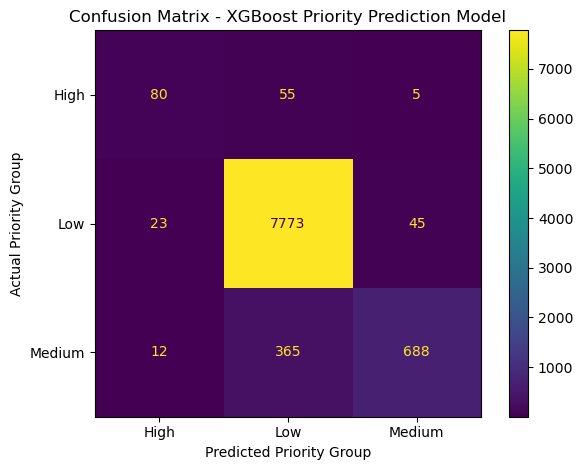

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgboost_predictions
)

plt.title("Confusion Matrix - XGBoost Priority Prediction Model")
plt.xlabel("Predicted Priority Group")
plt.ylabel("Actual Priority Group")
plt.tight_layout()
plt.show()

#### Final Evaluation Summary

The final XGBoost model achieved the best overall performance among all evaluated models, with an accuracy of **94.42%** and a Macro F1-score of **0.7867**.

The model performed very well on the majority Low priority class and showed strong overall classification ability. Its performance on Medium and High priority tickets is especially important because these classes are less frequent but more operationally significant.

Although the High priority class remains difficult due to its low representation in the dataset, XGBoost provided the best balance across all priority groups compared to the other tested models.

## Module 2: Incident Volume Forecasting

This module focuses on analyzing and forecasting incident volume over time. Forecasting ticket volume can help ABC Tech plan resources, staffing, and operational capacity more effectively.

### Monthly Incident Volume

Incident records are aggregated by month using the ticket opening time. This helps identify monthly ticket volume trends across the available historical data.

In [50]:
forecast_data = df.copy()

forecast_data = forecast_data.replace(r"^\s*$", np.nan, regex=True)
forecast_data = forecast_data.replace(["NA", "N/A", "nan", "NaN"], np.nan)

forecast_data["Open_Time"] = pd.to_datetime(
    forecast_data["Open_Time"],
    errors="coerce",
    dayfirst=True
)

monthly_incidents = (
    forecast_data
    .dropna(subset=["Open_Time"])
    .set_index("Open_Time")
    .resample("ME")
    .size()
    .reset_index(name="Incident_Count")
)

display(monthly_incidents.head())
display(monthly_incidents.tail())

,Open_Time,Incident_Count
0,2012-02-29,1
1,2012-03-31,2
2,2012-04-30,0
3,2012-05-31,0
4,2012-06-30,0


,Open_Time,Incident_Count
21,2013-11-30,8128
22,2013-12-31,6743
23,2014-01-31,8270
24,2014-02-28,7377
25,2014-03-31,6332


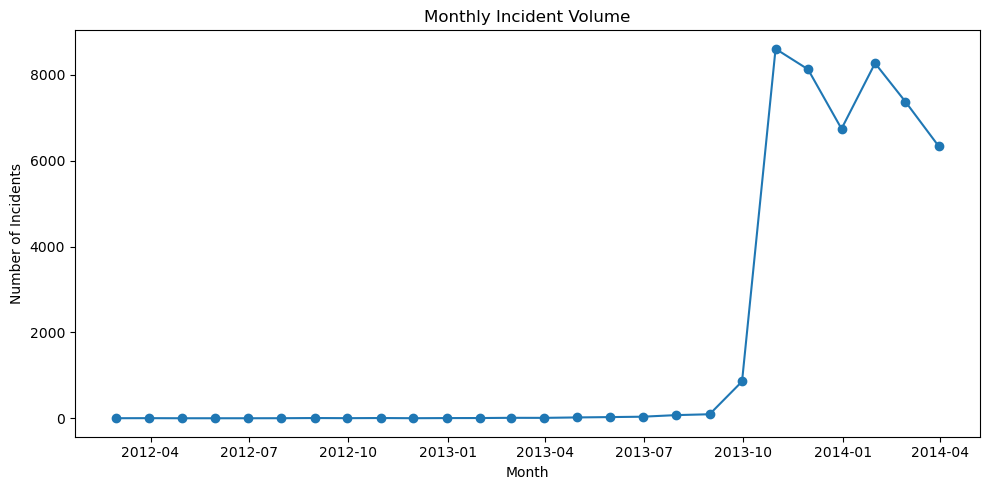

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_incidents["Open_Time"],
    monthly_incidents["Incident_Count"],
    marker="o"
)

plt.title("Monthly Incident Volume")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

#### Monthly Volume Summary

Monthly incident volume was calculated using the incident opening timestamp. This time-based aggregation provides a clear view of how ticket volume changes across months and supports forecasting for operational planning.

### Simple Moving Average Forecast

A simple moving average approach is used to forecast short-term incident volume. This method is easy to interpret and provides a practical baseline for resource planning.

In [52]:
monthly_incidents["Moving_Average_3"] = (
    monthly_incidents["Incident_Count"]
    .rolling(window=3)
    .mean()
)

display(monthly_incidents.tail())

,Open_Time,Incident_Count,Moving_Average_3
21,2013-11-30,8128,5863.666667
22,2013-12-31,6743,7825.666667
23,2014-01-31,8270,7713.666667
24,2014-02-28,7377,7463.333333
25,2014-03-31,6332,7326.333333


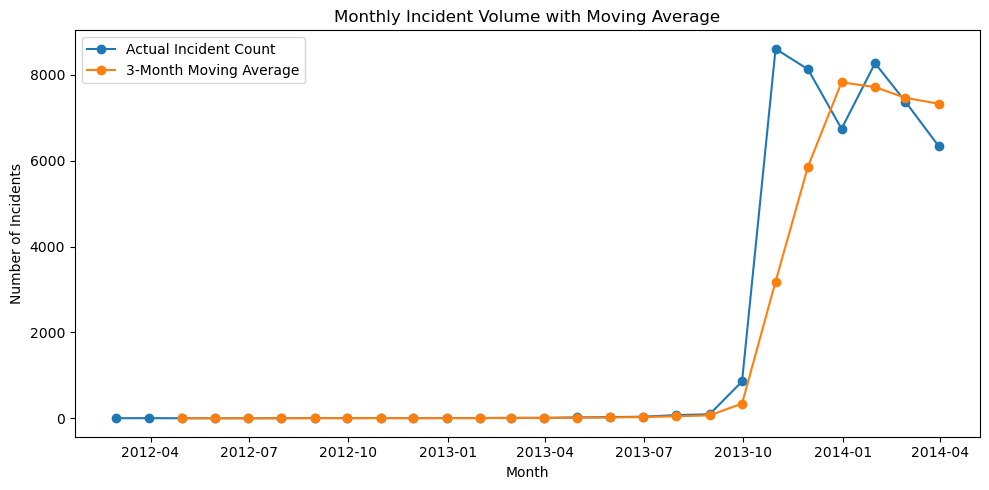

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_incidents["Open_Time"],
    monthly_incidents["Incident_Count"],
    marker="o",
    label="Actual Incident Count"
)

plt.plot(
    monthly_incidents["Open_Time"],
    monthly_incidents["Moving_Average_3"],
    marker="o",
    label="3-Month Moving Average"
)

plt.title("Monthly Incident Volume with Moving Average")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.legend()
plt.tight_layout()
plt.show()

### Forecasting Future Incident Volume

The average of the most recent three months is used as a simple forecast for the next three months. This provides a baseline estimate of expected ticket volume for short-term planning.

In [54]:
last_date = monthly_incidents["Open_Time"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=3,
    freq="ME"
)

forecast_value = monthly_incidents["Incident_Count"].tail(3).mean()

forecast_df = pd.DataFrame({
    "Open_Time": future_dates,
    "Forecasted_Incident_Count": [round(forecast_value)] * 3
})

display(forecast_df)

,Open_Time,Forecasted_Incident_Count
0,2014-04-30,7326
1,2014-05-31,7326
2,2014-06-30,7326


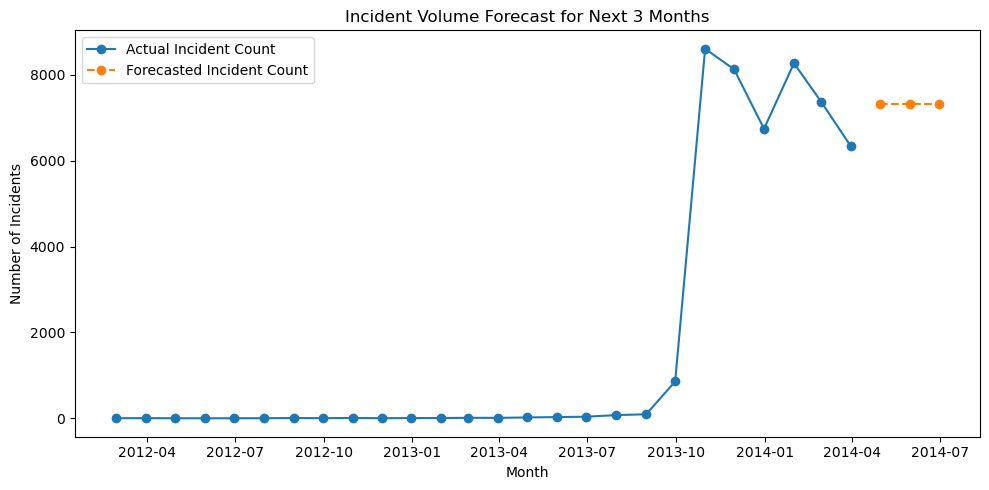

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_incidents["Open_Time"],
    monthly_incidents["Incident_Count"],
    marker="o",
    label="Actual Incident Count"
)

plt.plot(
    forecast_df["Open_Time"],
    forecast_df["Forecasted_Incident_Count"],
    marker="o",
    linestyle="--",
    label="Forecasted Incident Count"
)

plt.title("Incident Volume Forecast for Next 3 Months")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.legend()
plt.tight_layout()
plt.show()

#### Incident Volume Forecasting Summary

Monthly incident volume was analyzed using the incident opening timestamp. A 3-month moving average was used as a simple baseline forecasting method to estimate short-term future ticket volume.

This forecast can help ITSM teams plan staffing, resource allocation, and operational capacity. Since the available time range is limited, the forecast should be treated as a baseline estimate rather than a highly precise long-term prediction.

## Module 3: Ticket Auto-Tagging

This module focuses on automatically predicting the ticket category using available incident and configuration-item information. Auto-tagging can help reduce manual routing effort, minimize reassignment delays, and improve ITSM process efficiency.

Since a department or assignment group column is not available in the dataset, `Category` is used as the target variable for this module.

### Target Preparation

The `Category` column is selected as the target variable for ticket auto-tagging. Rare ticket categories are grouped into an `Other` category to make the classification problem more stable.

In [56]:
df_category = df_model.drop(columns=["Priority_Group"]).copy()

df_category["Category_Group"] = df_category["Category"].replace({
    "complaint": "Other",
    "request for change": "Other"
})

category_group_distribution = pd.DataFrame({
    "Count": df_category["Category_Group"].value_counts(),
    "Percentage": round(
        df_category["Category_Group"].value_counts(normalize=True) * 100,
        2
    )
})

display(category_group_distribution)

,Count,Percentage
Category_Group,,
incident,36413,80.51
request for information,8801,19.46
Other,12,0.03


### Feature and Target Separation

The original `Category` column and the newly created `Category_Group` target are separated from the predictor variables before model training.

In [57]:
X_category = df_category.drop(columns=["Category", "Category_Group"])
y_category = df_category["Category_Group"]

print("Feature Matrix Shape:", X_category.shape)
print("Target Shape:", y_category.shape)

Feature Matrix Shape: (45226, 14)
Target Shape: (45226,)


### Train-Test Split

The dataset is split into training and testing sets using stratification to preserve the category distribution across both sets.

In [58]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_category,
    y_category,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_category
)

print("X_train:", X_train_cat.shape)
print("X_test :", X_test_cat.shape)

display(y_train_cat.value_counts(normalize=True).round(4))
display(y_test_cat.value_counts(normalize=True).round(4))

X_train: (36180, 14)
X_test : (9046, 14)


Category_Group
incident                   0.8051
request for information    0.1946
Other                      0.0002
Name: proportion, dtype: float64

Category_Group
incident                   0.8051
request for information    0.1946
Other                      0.0003
Name: proportion, dtype: float64

### Preprocessing Pipeline

Categorical and numerical features are processed using imputation, One-Hot Encoding, and scaling inside a pipeline to avoid data leakage.

In [59]:
categorical_columns_cat = X_train_cat.select_dtypes(include="object").columns.tolist()
numerical_columns_cat = X_train_cat.select_dtypes(exclude="object").columns.tolist()

category_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns_cat),
        ("cat", categorical_transformer, categorical_columns_cat)
    ]
)

### XGBoost Category Tagging Model

XGBoost is trained for ticket category prediction because it performed strongly in the priority prediction module and is effective for structured tabular data.

In [60]:
category_label_encoder = LabelEncoder()

y_train_cat_encoded = category_label_encoder.fit_transform(y_train_cat)
y_test_cat_encoded = category_label_encoder.transform(y_test_cat)

xgb_category_model = Pipeline(steps=[
    ("preprocessor", category_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_category_model.fit(X_train_cat, y_train_cat_encoded)

category_predictions_encoded = xgb_category_model.predict(X_test_cat)
category_predictions = category_label_encoder.inverse_transform(category_predictions_encoded)

category_accuracy = accuracy_score(y_test_cat, category_predictions)
category_precision = precision_score(
    y_test_cat,
    category_predictions,
    average="macro",
    zero_division=0
)
category_recall = recall_score(
    y_test_cat,
    category_predictions,
    average="macro",
    zero_division=0
)
category_macro_f1 = f1_score(
    y_test_cat,
    category_predictions,
    average="macro",
    zero_division=0
)

print("Category Auto-Tagging Model")
print("Accuracy :", round(category_accuracy, 4))
print("Precision:", round(category_precision, 4))
print("Recall   :", round(category_recall, 4))
print("Macro F1 :", round(category_macro_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_cat,
    category_predictions,
    zero_division=0
))

Category Auto-Tagging Model
Accuracy : 0.9735
Precision: 0.9849
Recall   : 0.8472
Macro F1 : 0.9039

Classification Report:
                         precision    recall  f1-score   support

                  Other       1.00      0.67      0.80         3
               incident       0.97      1.00      0.98      7283
request for information       0.98      0.88      0.93      1760

               accuracy                           0.97      9046
              macro avg       0.98      0.85      0.90      9046
           weighted avg       0.97      0.97      0.97      9046



#### Ticket Auto-Tagging Summary

The XGBoost category auto-tagging model achieved an accuracy of **97.35%** and a Macro F1-score of **0.9039**, indicating strong overall performance.

The model performed especially well for the dominant `incident` category and also showed strong performance for `request for information`. The `Other` category had only **3 records** in the test set, so its score should not be over-interpreted.

Overall, the auto-tagging model shows that machine learning can effectively support ticket category prediction and reduce manual classification effort in the ITSM process.

## Module 4: Change Request Risk Analysis

This module analyzes change-related information in the ITSM dataset to identify possible operational risk patterns. Since the dataset does not contain a direct change failure or misconfiguration target variable, this module is treated as an analytical risk assessment rather than a supervised machine learning model.

### Change-Related Records

The available change-related fields are analyzed to understand how many incidents are associated with change requests and whether these records show patterns related to ticket priority or reassignment.

In [61]:
change_analysis = df.copy()

change_analysis = change_analysis.replace(r"^\s*$", np.nan, regex=True)
change_analysis = change_analysis.replace(["NA", "N/A", "nan", "NaN"], np.nan)

change_analysis["Priority"] = pd.to_numeric(
    change_analysis["Priority"],
    errors="coerce"
)

change_analysis["No_of_Related_Changes"] = pd.to_numeric(
    change_analysis["No_of_Related_Changes"],
    errors="coerce"
)

change_analysis["No_of_Reassignments"] = pd.to_numeric(
    change_analysis["No_of_Reassignments"],
    errors="coerce"
)

change_analysis = change_analysis.dropna(subset=["Priority"])

def group_priority(priority):
    if priority in [1, 2]:
        return "High"
    elif priority == 3:
        return "Medium"
    elif priority in [4, 5]:
        return "Low"
    else:
        return np.nan

change_analysis["Priority_Group"] = change_analysis["Priority"].apply(group_priority)

change_analysis = change_analysis.dropna(subset=["Priority_Group"])

change_analysis["Has_Related_Change"] = (
    change_analysis["No_of_Related_Changes"]
    .fillna(0)
    .apply(lambda x: 1 if x > 0 else 0)
)

change_distribution = pd.DataFrame({
    "Count": change_analysis["Has_Related_Change"].value_counts(),
    "Percentage": round(
        change_analysis["Has_Related_Change"].value_counts(normalize=True) * 100,
        2
    )
})

display(change_distribution)

,Count,Percentage
Has_Related_Change,,
0,44701,98.84
1,525,1.16


### Related Change and Priority Group

The relationship between related change records and ticket priority is analyzed to determine whether incidents linked to changes are associated with higher priority levels.

In [62]:
change_priority = pd.crosstab(
    change_analysis["Has_Related_Change"],
    change_analysis["Priority_Group"],
    normalize="index"
).round(2)

display(change_priority)

Priority_Group,High,Low,Medium
Has_Related_Change,,,
0,0.01,0.87,0.12
1,0.06,0.75,0.19


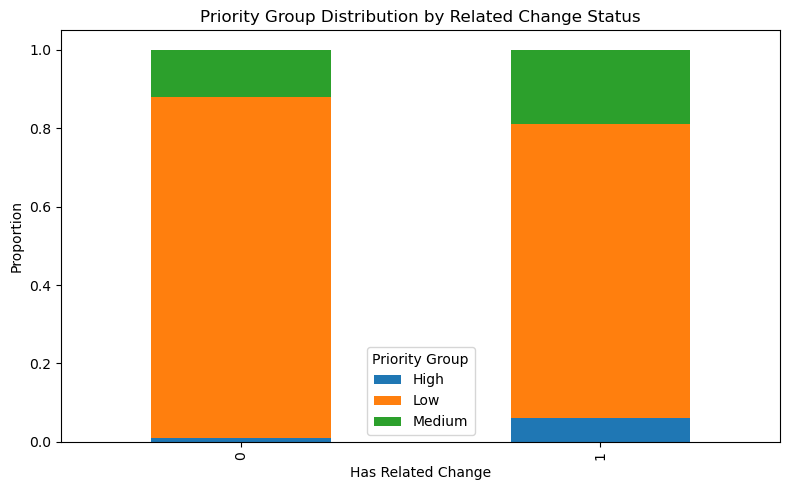

In [63]:
change_priority.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Priority Group Distribution by Related Change Status")
plt.xlabel("Has Related Change")
plt.ylabel("Proportion")
plt.legend(title="Priority Group")
plt.tight_layout()
plt.show()

### Related Change and Reassignment Analysis

The number of reassignments is compared between incidents with and without related change records. Higher reassignment counts may indicate operational complexity or routing inefficiency.

In [64]:
reassignment_by_change = change_analysis.groupby("Has_Related_Change")["No_of_Reassignments"].describe()

display(reassignment_by_change)

,count,mean,std,min,25%,50%,75%,max
Has_Related_Change,,,,,,,,
0,44700.0,1.139620,2.274746,0.0,0.0,0.0,2.0,46.0
1,525.0,1.262857,2.999277,0.0,0.0,0.0,1.0,27.0


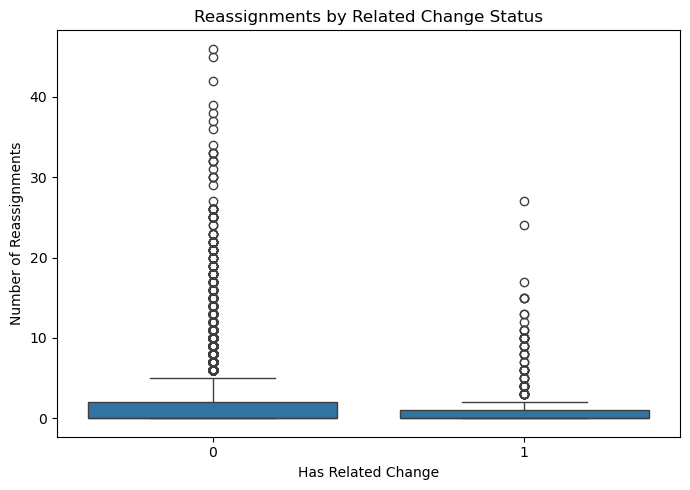

In [65]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=change_analysis,
    x="Has_Related_Change",
    y="No_of_Reassignments"
)

plt.title("Reassignments by Related Change Status")
plt.xlabel("Has Related Change")
plt.ylabel("Number of Reassignments")
plt.tight_layout()
plt.show()

#### Change Request Risk Analysis Summary

The dataset does not contain a direct label indicating whether a change request failed or caused a misconfiguration. Therefore, supervised prediction of change failure could not be performed.

Only **1.16%** of valid priority records were linked to related changes. However, incidents with related changes showed a higher proportion of High priority tickets compared to incidents without related changes. Tickets with related changes also showed a slightly higher average reassignment count.

This suggests that change-linked incidents may be operationally more complex and should be monitored carefully. For a complete change failure prediction model, additional fields such as change status, implementation result, rollback flag, failure indicator, or post-change incident linkage would be required.

## Final Business Recommendations

Based on the analysis and machine learning modules developed in this project, the following recommendations are proposed for ABC Tech.

#### 1. Use Priority Prediction for Early Ticket Escalation

The XGBoost priority prediction model can be used to identify High, Medium, and Low priority tickets using incident-related, configuration-item, category, reassignment, and time-based features.

Since High priority tickets are rare but operationally important, the model should be used as a decision-support tool to flag potentially critical incidents early. These flagged tickets can be reviewed by the ITSM team for faster escalation and response.

#### 2. Use Incident Volume Forecasting for Resource Planning

Monthly incident volume forecasting can help ABC Tech estimate expected ticket load for upcoming periods. This can support staffing decisions, workload planning, and resource allocation.

The simple moving average forecast provides a baseline estimate. For production use, ABC Tech can improve forecasting accuracy by using longer historical data and advanced time-series models.

#### 3. Use Auto-Tagging to Improve Ticket Routing

The ticket auto-tagging model can help classify tickets into appropriate categories, reducing manual tagging effort and improving routing efficiency.

This can reduce reassignment delays, improve first-level ticket handling, and support faster incident resolution.

#### 4. Monitor Change-Linked Incidents as Higher-Risk Cases

The change request risk analysis showed that only a small portion of incidents are linked to related changes, but these incidents may be more complex and operationally sensitive.

ABC Tech should monitor change-linked incidents more carefully and collect additional change-management fields such as change status, rollback indicator, failure flag, implementation result, and post-change incident linkage.

#### 5. Improve Data Collection for Better ML Outcomes

The current dataset supports priority prediction, volume forecasting, auto-tagging, and basic change-risk analysis. However, stronger models can be developed if additional fields such as ticket descriptions, assignment groups, SLA breach indicators, resolution notes, and change outcome labels are collected.

Better data quality and richer ticket information will improve model reliability and business usefulness.

## Project Limitations

Although this project addresses the major business objectives outlined for ITSM process improvement, there are some limitations that should be considered.

#### 1. High Class Imbalance

The priority prediction target is highly imbalanced, with High priority tickets forming only a small percentage of the dataset. This makes it harder for the model to learn patterns for rare but business-critical incidents.

#### 2. Priority Leakage Risk

The original `Priority` column is closely related to `Impact` and `Urgency` through the priority matrix. To avoid data leakage, `Impact` and `Urgency` were removed from the priority prediction model. However, this also makes the prediction task more difficult.

#### 3. Limited Change Request Information

The dataset does not contain a direct label for change failure, misconfiguration, rollback, or change success. Therefore, the change request module was limited to risk analysis rather than supervised failure prediction.

#### 4. Limited Textual Information

The dataset does not include detailed incident descriptions, resolution notes, or user comments. These text fields could provide valuable information for priority prediction, auto-tagging, and root-cause analysis.

#### 5. Basic Forecasting Approach

Incident volume forecasting was performed using a simple moving average approach. This provides an interpretable baseline, but more advanced forecasting models may be required for production-level planning.

#### 6. Dataset Scope

The dataset contains historical ITSM records from a limited time period. Model performance may vary when applied to newer tickets, different business units, or changing ITSM processes.

## Future Scope

This project can be further improved and extended in the following ways.

#### 1. Advanced Priority Prediction

Future versions can apply advanced imbalance-handling techniques such as SMOTE, class-weight optimization, threshold tuning, or cost-sensitive learning to improve detection of High priority tickets.

#### 2. Use of Text Data

If ticket descriptions, resolution notes, or user comments are available, Natural Language Processing techniques can be applied to extract meaningful information from text and improve prediction accuracy.

#### 3. Department or Assignment Group Prediction

The auto-tagging module can be extended to predict the correct assignment group or department if such fields are available. This would directly support automated ticket routing and reduce reassignment delays.

#### 4. Advanced Forecasting Models

Incident volume forecasting can be improved using time-series models such as ARIMA, Prophet, exponential smoothing, or machine learning-based forecasting models. This can provide more reliable quarterly and yearly planning insights.

#### 5. Change Failure Prediction

A supervised change failure prediction model can be developed if additional change-management fields are collected, such as change status, rollback flag, implementation result, failure reason, or post-change incident linkage.

#### 6. Model Explainability

Feature importance, SHAP, or permutation importance can be used to explain model predictions and help ITSM teams understand which factors contribute most to ticket priority and category prediction.

#### 7. Dashboard and Deployment

The final models can be deployed as an ITSM decision-support dashboard to provide real-time priority prediction, category tagging, ticket volume monitoring, and change-risk alerts.

## Conclusion

This project developed a client-style ITSM process optimization solution for ABC Tech using data analytics and machine learning. The project addressed multiple business objectives, including priority prediction, incident volume forecasting, ticket auto-tagging, and change request risk analysis.

The dataset was extracted from a MySQL database and inspected for structure, missing values, data types, and target distribution. Initial inspection showed that several missing values were stored as blank strings or placeholder values, so data cleaning and type conversion were performed before analysis.

For priority prediction, the original priority levels were grouped into High, Medium, and Low priority categories. Since `Impact` and `Urgency` were closely related to the priority matrix, they were removed from the modeling features to reduce target leakage. Multiple classification models were evaluated, and XGBoost achieved the best performance for priority prediction.

Incident volume forecasting was performed using monthly ticket counts and a moving average baseline to support resource planning. Ticket auto-tagging was performed by predicting ticket category groups, where XGBoost showed strong classification performance. Change request risk analysis was handled as an analytical module because the dataset did not contain a direct change failure target.

Overall, this project demonstrates how machine learning can support ITSM process improvement by enabling early ticket prioritization, better workload planning, automated ticket tagging, and preliminary change-related risk monitoring. The solution provides a strong foundation for future enhancement using richer ticket data, advanced forecasting models, explainability techniques, and deployment as an ITSM decision-support dashboard.

## Final Project Report

### Project Overview

This project was developed as a client-style ITSM machine learning solution for ABC Tech. The main objective was to improve ITSM operations using data analytics and machine learning across four business areas: high priority ticket prediction, incident volume forecasting, ticket auto-tagging, and change request risk analysis.

The data was extracted from a MySQL database and loaded into a pandas DataFrame for analysis. The dataset contained **46,606 incident records** and **25 columns**, including ticket details, configuration item information, priority-related fields, timestamps, reassignment counts, closure information, and related interaction/change details.

### Data Understanding and Cleaning

Initial inspection showed that all columns were imported as object data types, including numeric and datetime fields. Although the first missing value check showed no null values, further inspection revealed that missing values were stored as blank strings or placeholder values such as `NA`.

Data cleaning included:

- Converting blank strings and placeholder values into proper missing values.
- Converting numeric columns into numerical data types.
- Converting timestamp columns into datetime format.
- Removing low-value, high-missing, identifier, and post-resolution leakage columns.
- Creating a clean modeling dataset for machine learning.

The original `Priority` column contained five priority levels and missing values. Since Priority 1 had very few records, the priority levels were grouped into three business-relevant classes: **High**, **Medium**, and **Low** priority.

### Exploratory Data Analysis

EDA showed that the grouped priority target was highly imbalanced. Low priority tickets formed the majority class with **39,203 records**, followed by Medium priority tickets with **5,323 records**, and High priority tickets with only **700 records**.

The dataset was mainly dominated by incident records, confirming that it is highly relevant for incident management analysis. Time-based analysis also showed clear operational patterns across years, months, weekdays, and business hours.

A leakage check showed that `Impact` and `Urgency` were closely related to the priority matrix. Therefore, these columns were removed from the priority prediction model to build a more realistic machine learning solution.

### Module 1: High Priority Ticket Prediction

The first module focused on predicting grouped ticket priority using incident-related, categorical, operational, and time-based features.

Several models were evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and CatBoost. Since the target was highly imbalanced, **Macro F1-score** was used as the primary evaluation metric.

XGBoost achieved the best performance with:

- Accuracy: **94.42%**
- Macro F1-score: **0.7867**

Based on the model comparison, XGBoost was selected as the final priority prediction model.

### Module 2: Incident Volume Forecasting

The second module focused on forecasting incident volume over time. Monthly ticket counts were generated using the incident opening timestamp.

A simple 3-month moving average method was used as a baseline forecasting approach. This provided a practical and interpretable way to estimate short-term future ticket volume and support staffing, workload planning, and resource allocation.

### Module 3: Ticket Auto-Tagging

The third module focused on automatic ticket category prediction. Since assignment group or department information was not available in the dataset, `Category` was used as the target variable for auto-tagging.

Rare categories were grouped into an `Other` class to make the classification task more stable. XGBoost was trained for category prediction and achieved:

- Accuracy: **97.35%**
- Macro F1-score: **0.9039**

The result shows that machine learning can effectively support automatic ticket tagging and reduce manual classification effort.

### Module 4: Change Request Risk Analysis

The fourth module analyzed change-related records. Since the dataset did not contain a direct change failure or misconfiguration target, supervised change failure prediction was not possible.

Instead, change-related risk was analyzed using related change counts, priority groups, and reassignment counts. Only a small portion of records were linked to related changes, but change-linked incidents showed signs of higher operational complexity.

This module provides a preliminary risk assessment and highlights the need for additional change-management fields such as change status, rollback indicator, implementation result, and failure flag.

### Business Value

This project provides practical value to ABC Tech by supporting:

- Early identification of high priority incidents.
- Better resource planning through ticket volume forecasting.
- Faster ticket routing through category auto-tagging.
- Preliminary monitoring of change-linked operational risks.
- Improved decision-making in ITSM incident management.

### Final Summary

The project successfully addresses the major business goals described in the client requirement. It combines database extraction, data cleaning, EDA, machine learning classification, forecasting, risk analysis, and business recommendations into one complete ITSM process optimization solution.

The final solution shows that machine learning can help ABC Tech improve incident prioritization, reduce manual effort, support resource planning, and strengthen ITSM operational decision-making.